# PARISIM demo

Compare strings with many similarity methods at once, then keep the ones that suit your data.

This notebook uses pandas and matplotlib: `pip install "parisim[pandas,viz]"`.

## 1. Compare two strings

In [1]:
from parisim import Matcher

m = Matcher()
m.compare("voiture rouge", "automobile rouge")

MatchResult('voiture rouge' vs 'automobile rouge')
  jaro_winkler   0.754
  partial_ratio  0.750
  indel_ratio    0.621
  token_set      0.621
  levenshtein    0.500
  soundex        0.500
  metaphone      0.500
  token_sort     0.414
  tfidf_cosine   0.336

Each method has its own scale: compare a method's scores across pairs, never the scores of two different methods.

The built-in methods fall into four categories:

In [2]:
{
    category: Matcher(categories=category).methods
    for category in Matcher.available_categories()
}

{'character': ['levenshtein',
  'indel_ratio',
  'hamming',
  'jaro_winkler',
  'partial_ratio'],
 'token': ['token_sort', 'token_set', 'tfidf_cosine'],
 'phonetic': ['soundex', 'metaphone'],
 'semantic': ['embedding']}

## 2. What each method is sensitive to

Common variations of the same name, one row per variation and one column per method. `hamming` only applies to strings of equal length, hence the NaN.

In [3]:
import pandas as pd

variants = pd.Series(
    {
        "typo": "Jean Dupond",
        "word order": "Dupont Jean",
        "extra word": "Jean Dupont Jr",
        "initial": "J. Dupont",
        "sounds alike": "Jhon Dupond",
        "unrelated": "Marie Curie",
    }
)
scores = m.compare_one_to_many("Jean Dupont", variants).to_pandas()
scores.index = variants.index
scores.drop(columns=["str1", "str2"]).round(2)

,levenshtein,indel_ratio,hamming,jaro_winkler,partial_ratio,token_sort,token_set,tfidf_cosine,soundex,metaphone
typo,0.91,0.91,0.91,0.96,0.95,0.91,0.91,0.34,1.00,1.00
word order,0.09,0.55,0.00,0.52,0.71,1.00,1.00,1.00,1.00,1.00
extra word,0.79,0.88,NaN,0.96,1.00,0.88,1.00,0.71,0.67,0.67
initial,0.73,0.80,NaN,0.77,0.88,0.80,0.80,0.58,0.50,0.50
sounds alike,0.73,0.73,0.73,0.84,0.76,0.73,0.73,0.00,1.00,0.50
unrelated,0.09,0.27,0.00,0.49,0.33,0.27,0.27,0.00,0.00,0.00


- `levenshtein`, `indel_ratio`, `jaro_winkler`: typos; `jaro_winkler` rewards a common start.
- `token_sort` ignores word order, `token_set` also ignores extra words, `partial_ratio` finds substrings.
- `soundex` and `metaphone` compare pronunciations (English rules), word by word.
- `tfidf_cosine` measures shared vocabulary: exact words only.

## 3. Preprocessing

`normalize` casefolds, strips accents and replaces punctuation with spaces. Any `str -> str` function works too, e.g. `preprocess=[str.lower, strip_accents]`.

In [4]:
from parisim import normalize

print(normalize("  Jean-François   L'HÔPITAL! "))
Matcher("levenshtein", preprocess=normalize).compare("JEAN-FRANÇOIS", "jean francois")

jean francois l hopital


MatchResult('JEAN-FRANÇOIS' vs 'jean francois')
  levenshtein  1.000

## 4. Pick methods with labelled pairs

Given pairs labelled as duplicates or not, look for the methods whose scores differ most between the two groups:

In [5]:
pairs = pd.DataFrame(
    [
        ("Jean Dupont", "Dupont Jean", True),
        ("Marie Curie", "M. Curie", True),
        ("Société Générale", "Societe Generale SA", True),
        ("12 rue de la Paix", "12, rue de la paix", True),
        ("Philippe Martin", "Filip Martin", True),
        ("Jean Dupont", "Jean Durand", False),
        ("Marie Curie", "Maria Callas", False),
        ("12 rue de la Paix", "21 rue de la Paix", False),
        ("Société Générale", "Crédit Agricole", False),
        ("Philippe Martin", "Philippe Morin", False),
    ],
    columns=["a", "b", "duplicate"],
)
m = Matcher(preprocess=normalize)
batch = m.compare_batch(zip(pairs["a"], pairs["b"], strict=True))
scores = batch.to_pandas().assign(duplicate=pairs["duplicate"])

means = scores.groupby("duplicate").mean(numeric_only=True).T
means["gap"] = means[True] - means[False]
means["scored"] = scores.count()
means.sort_values("gap", ascending=False).round(2)

duplicate,False,True,gap,scored
tfidf_cosine,0.27,0.73,0.46,10
metaphone,0.46,0.83,0.37,10
soundex,0.46,0.73,0.27,10
token_set,0.72,0.93,0.21,10
partial_ratio,0.76,0.89,0.13,10
token_sort,0.72,0.83,0.11,10
indel_ratio,0.72,0.81,0.09,10
levenshtein,0.65,0.66,0.02,10
jaro_winkler,0.84,0.81,-0.02,10
hamming,0.80,0.50,-0.30,4


`scored` is the number of pairs each method returned a score for: `hamming` only applies to the 4 pairs of equal length, too few to judge it. The gap also depends on each method's scale. With more pairs, prefer a metric that does not, such as `sklearn.metrics.roc_auc_score` (drop the NaN first), and choose a threshold per method.

## 5. Charts

`plot()` returns a matplotlib `Axes` and accepts `ax=` to draw into your own figure.

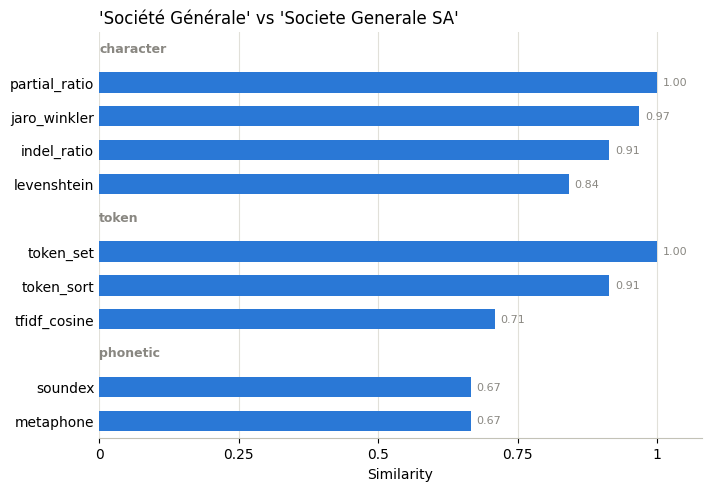

In [6]:
m.compare("Société Générale", "Societe Generale SA").plot();

Over a batch, the distribution of each method's scores:

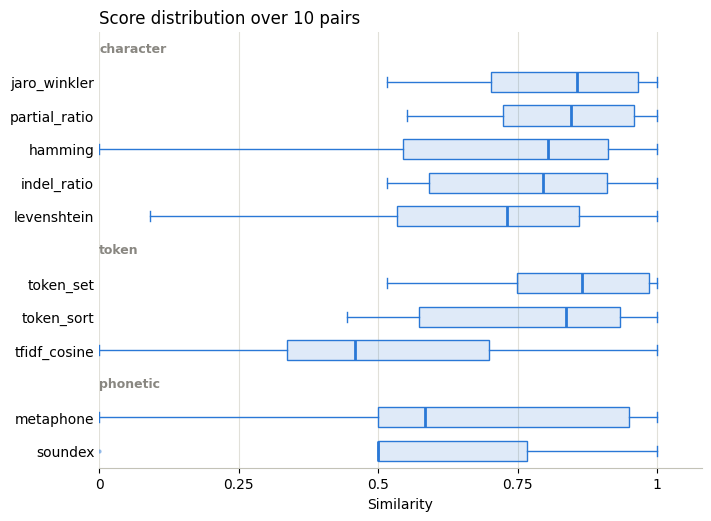

In [7]:
batch.plot();

## 6. Semantic similarity

Character and word methods cannot tell that *voiture* and *automobile* mean the same. Embeddings can. The built-in `embedding` method is opt-in: it needs `pip install 'parisim[embeddings]'` and downloads a 0.22 GB multilingual model (Apache-2.0) on first use.

In [8]:
Matcher(["levenshtein", "embedding"]).compare("voiture rouge", "automobile rouge")

MatchResult('voiture rouge' vs 'automobile rouge')
  embedding    0.996
  levenshtein  0.500

`Embedding` takes a model name (fastembed or sentence-transformers backend) or any function turning a list of texts into vectors, such as an embedding API:

```python
from openai import OpenAI
from parisim import Embedding

client = OpenAI()

def openai_encode(texts):
    response = client.embeddings.create(input=texts, model="text-embedding-3-small")
    return [item.embedding for item in response.data]

m.add_method("openai", Embedding(openai_encode))
```

A toy encoder shows the mechanics:

In [9]:
from parisim import Embedding


def count_vowels(texts):
    return [[text.count(vowel) for vowel in "aeiou"] for text in texts]


toy = Matcher(methods=[])
toy.add_method("vowels", Embedding(count_vowels))
toy.compare("banana", "papaya")

MatchResult('banana' vs 'papaya')
  vowels  1.000

## 7. Custom methods

Any function `(a, b) -> float` returning a similarity in [0, 1], or `None` when it does not apply:

In [10]:
from functools import partial

from parisim.methods import tfidf_cosine

m = Matcher(categories="token")
m.add_method("same_initial", lambda a, b: float(a[:1].lower() == b[:1].lower()))
m.add_method("tfidf_1_letter", partial(tfidf_cosine, token_pattern=r"(?u)\b\w+\b"))
m.compare("J Dupont", "Jean Dupont")

MatchResult('J Dupont' vs 'Jean Dupont')
  same_initial    1.000
  token_set       0.857
  token_sort      0.842
  tfidf_cosine    0.580
  tfidf_1_letter  0.336

## 8. Errors

Missing values are rejected with a clear message rather than scored:

In [11]:
try:
    Matcher().compare_batch([("Jean", "Jan"), ("Marie", float("nan"))])
except TypeError as error:
    print(error)

pair 1: expected str, got float nan (missing value? drop or fill NaN/None first)


A failing method does not stop the others: the error is recorded and a warning is emitted. Pass `strict=True` to raise instead.

In [12]:
m = Matcher("levenshtein")
m.add_method("fragile", lambda a, b: 1 / len(a))
m.compare("", "abc")

/var/folders/7w/vh6dwvgn17sgxvcdjz7920gm0000gp/T/ipykernel_66332/73596581.py:3: RuntimeWarning: method 'fragile' failed on 1 of 1 pair(s): ZeroDivisionError: division by zero. See MatchResult.errors, or pass strict=True to raise instead.
  m.compare("", "abc")


MatchResult('' vs 'abc')
  levenshtein  0.000
  fragile      failed: ZeroDivisionError: division by zero